# Department & Division Analysis

This notebook analyzes UCSD CAPEs data sliced by:
- **Department** (e.g. CSE, MATH, ECE)
- **Division** (Lower: 1–99, Upper: 100–199, Grad: 200+)

Author: Minghong Sun

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
from pathlib import Path

# Paths
root_dir = Path().resolve().parents[0]
data_dir = root_dir / 'data' / 'capes_data.csv'

df_raw = pd.read_csv(data_dir)
print(f'Loaded {len(df_raw):,} rows')
df_raw.head(3)

Loaded 63,363 rows


,Instructor,Course,Quarter,Total Enrolled in Course,Total CAPEs Given,Percentage Recommended Class,Percentage Recommended Professor,Study Hours per Week,Average Grade Expected,Average Grade Received,Evalulation URL
0,Butler Elizabeth Annette,AAS 10 - Intro/African-American Studies (A),SP23,66,48,93.5%,100.0%,2.80,A- (3.84),B+ (3.67),https://cape.ucsd.edu/CAPEReport.aspx?sectioni...
1,Butler Elizabeth Annette,AAS 170 - Legacies of Research (A),SP23,20,7,100.0%,100.0%,2.50,A- (3.86),A- (3.92),https://cape.ucsd.edu/CAPEReport.aspx?sectioni...
2,Jones Ian William Nasser,ANAR 111 - Foundations of Archaeology (A),SP23,16,3,100.0%,100.0%,3.83,B+ (3.67),NaN,https://cape.ucsd.edu/CAPEReport.aspx?sectioni...


## 2. Data Cleaning & Feature Extraction

In [2]:
df = df_raw.copy()

# --- Clean percentage columns ---
df['Pct_Rec_Class'] = df['Percentage Recommended Class'].str.replace('%', '', regex=False).astype(float)
df['Pct_Rec_Prof'] = df['Percentage Recommended Professor'].str.replace('%', '', regex=False).astype(float)

# --- Extract GPA from '(3.84)' format ---
df['GPA_Expected'] = df['Average Grade Expected'].str.extract(r'\(([\d.]+)\)').astype(float)
df['GPA_Received'] = df['Average Grade Received'].str.extract(r'\(([\d.]+)\)').astype(float)

# --- Extract department code from Course (e.g. 'CSE 11 - ...' -> 'CSE') ---
df['Department'] = df['Course'].str.extract(r'^([A-Z]+(?:\s[A-Z]+)?)\s+\d')

# --- Extract course number (e.g. 'CSE 11 - ...' -> 11) ---
df['Course_Number'] = df['Course'].str.extract(r'([A-Z]+(?:\s[A-Z]+)?)\s+(\d+)')[1].astype(float)

# --- Classify division ---
def classify_division(num):
    if pd.isna(num):
        return 'Unknown'
    elif num < 100:
        return 'Lower Division (1-99)'
    elif num < 200:
        return 'Upper Division (100-199)'
    else:
        return 'Graduate (200+)'

df['Division'] = df['Course_Number'].apply(classify_division)

# --- Parse Quarter to sortable year+quarter ---
# Quarter codes: FA=Fall, WI=Winter, SP=Spring, SU=Summer
quarter_order = {'WI': 1, 'SP': 2, 'SU': 3, 'FA': 4}

def parse_quarter(q):
    """Return a sortable float: year + fractional quarter (e.g. FA23 -> 2023.75)"""
    m = re.match(r'([A-Z]+)(\d{2})$', str(q))
    if not m:
        return None
    season, yr2 = m.group(1), int(m.group(2))
    year = 2000 + yr2
    frac = quarter_order.get(season, 0) / 4
    return year + frac

df['Quarter_Num'] = df['Quarter'].apply(parse_quarter)
df['Year'] = df['Quarter'].str.extract(r'(\d{2})$').astype(float) + 2000

# Drop rows without GPA
df_clean = df.dropna(subset=['GPA_Received', 'Quarter_Num', 'Department'])
print(f'Clean rows (with GPA_Received): {len(df_clean):,}')
print(f'Unique departments: {df_clean["Department"].nunique()}')
print(f'Division breakdown:')
print(df_clean['Division'].value_counts())

Clean rows (with GPA_Received): 41,179
Unique departments: 126
Division breakdown:
Division
Upper Division (100-199)    27194
Lower Division (1-99)       13985
Name: count, dtype: int64


## 3. Load LLM Release Dates

In [3]:
gpt_df    = pd.read_csv(root_dir / 'data' / 'chatgpt_model_updates.csv')
claude_df = pd.read_csv(root_dir / 'data' / 'claude_model_updates.csv')
gemini_df = pd.read_csv(root_dir / 'data' / 'gemini_model_updates.csv')
grok_df   = pd.read_csv(root_dir / 'data' / 'grok_model_updates.csv')

# Show columns so we know how to parse dates
print('GPT columns:', gpt_df.columns.tolist())
gpt_df.head(3)

GPT columns: ['Time', 'Model']


,Time,Model
0,June 2018,GPT-1
1,February 2019,GPT2
2,June 2020,GPT-3


In [4]:
# Parse release dates to numeric year (matching Quarter_Num scale)
date_col  = gpt_df.columns[0]   # first col is date
model_col = gpt_df.columns[1]   # second col is model name

def df_to_events(df):
    dates = pd.to_datetime(df.iloc[:, 0], errors='coerce')
    models = df.iloc[:, 1].astype(str)
    return list(zip(dates.dt.year + dates.dt.month / 12, models))

gpt_events    = df_to_events(gpt_df)
claude_events = df_to_events(claude_df)
gemini_events = df_to_events(gemini_df)
grok_events   = df_to_events(grok_df)

# Only keep events within CAPES range (2007-2023) + a bit beyond
all_llm_events = [(t, m, 'GPT')    for t, m in gpt_events    if 2020 <= t <= 2024] + \
                 [(t, m, 'Claude')  for t, m in claude_events  if 2020 <= t <= 2024] + \
                 [(t, m, 'Gemini')  for t, m in gemini_events  if 2020 <= t <= 2024] + \
                 [(t, m, 'Grok')    for t, m in grok_events    if 2020 <= t <= 2024]

print(f'LLM events in range: {len(all_llm_events)}')
for t, m, brand in sorted(all_llm_events):
    print(f'  {t:.2f}  [{brand}] {m}')

LLM events in range: 8
  2020.50  [GPT] GPT-3
  2022.92  [GPT] GPT-3.5
  2023.25  [Claude] Claude 1
  2023.25  [GPT] GPT-4
  2023.58  [Claude] Claude 2
  2023.92  [Claude] Claude 2.1
  2023.92  [Grok] Grok-1
  2024.00  [Gemini] Gemini 1.0


C:\Users\admin\AppData\Local\Temp\ipykernel_28700\109318132.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df.iloc[:, 0], errors='coerce')
C:\Users\admin\AppData\Local\Temp\ipykernel_28700\109318132.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df.iloc[:, 0], errors='coerce')
C:\Users\admin\AppData\Local\Temp\ipykernel_28700\109318132.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df.iloc[:, 0], errors='coerce')
C:\Users\admin\AppData\Local\Temp\ipykernel_28700\109318132.py:6: UserWarning: 

## 4. Department Analysis

### 4.1 Top 15 Departments by Record Count

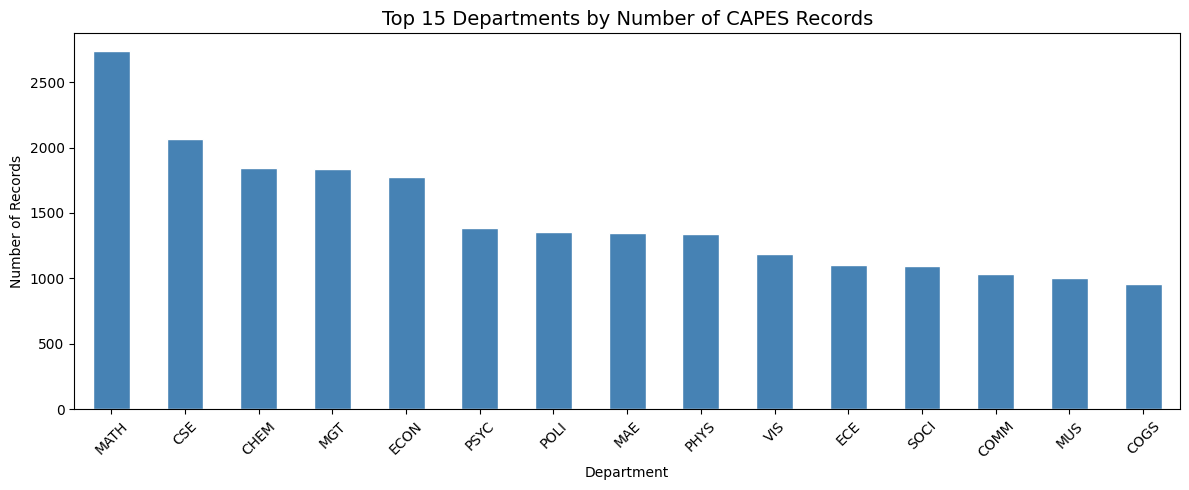

Top 15 departments: ['MATH', 'CSE', 'CHEM', 'MGT', 'ECON', 'PSYC', 'POLI', 'MAE', 'PHYS', 'VIS', 'ECE', 'SOCI', 'COMM', 'MUS', 'COGS']


In [5]:
top15_depts = df_clean['Department'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
top15_depts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Departments by Number of CAPES Records', fontsize=14)
ax.set_xlabel('Department')
ax.set_ylabel('Number of Records')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('figures/dept_record_count.png', dpi=150)
plt.show()

TOP_DEPTS = top15_depts.index.tolist()
print('Top 15 departments:', TOP_DEPTS)

### 4.2 Average GPA Received by Department (Top 15)

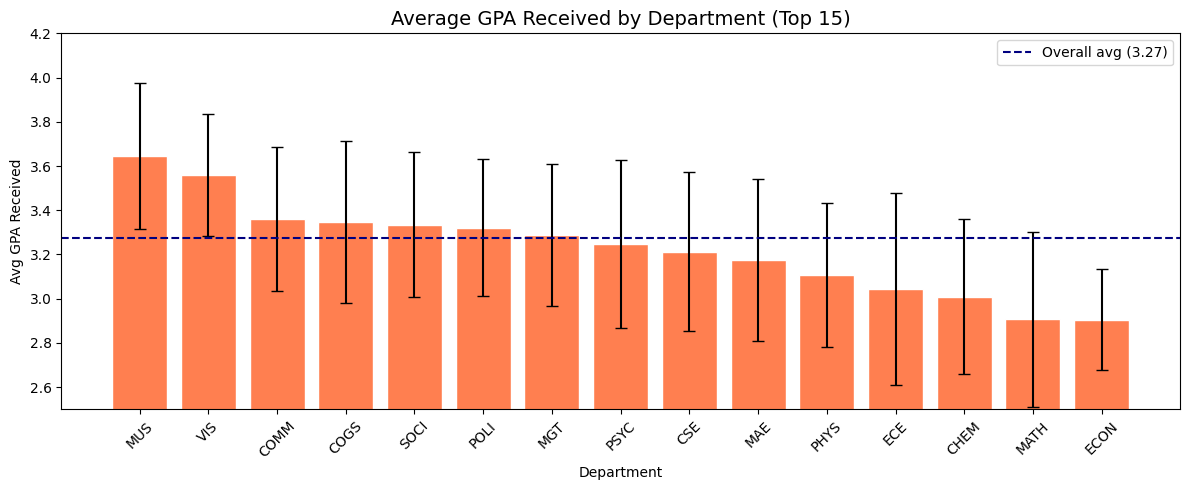

In [6]:
dept_gpa = (
    df_clean[df_clean['Department'].isin(TOP_DEPTS)]
    .groupby('Department')['GPA_Received']
    .agg(['mean', 'std', 'count'])
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(dept_gpa.index, dept_gpa['mean'],
       yerr=dept_gpa['std'], capsize=4,
       color='coral', edgecolor='white')
ax.axhline(df_clean['GPA_Received'].mean(), color='navy', linestyle='--',
           linewidth=1.5, label=f'Overall avg ({df_clean["GPA_Received"].mean():.2f})')
ax.set_title('Average GPA Received by Department (Top 15)', fontsize=14)
ax.set_xlabel('Department')
ax.set_ylabel('Avg GPA Received')
ax.set_ylim(2.5, 4.2)
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('figures/dept_avg_gpa.png', dpi=150)
plt.show()

### 4.3 GPA Trend Over Time — Focus Departments (CSE, MATH, ECE, ECON)

Plotting departments: ['CSE', 'MATH', 'ECE', 'ECON']


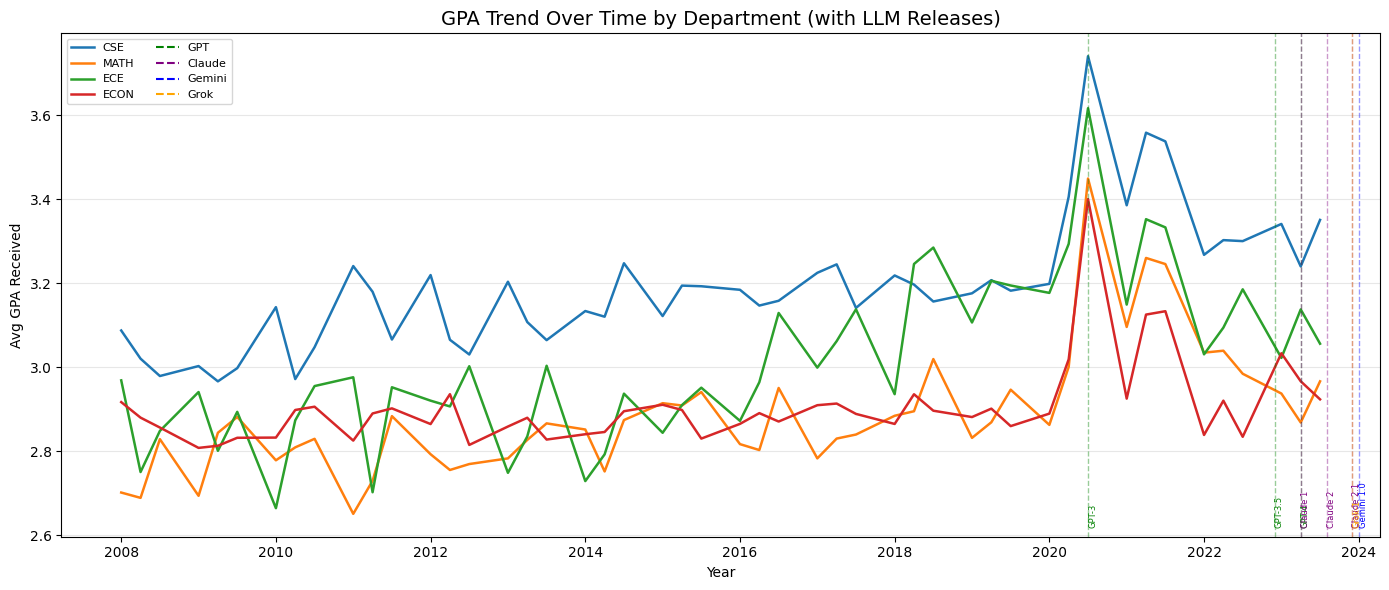

In [7]:
FOCUS_DEPTS = ['CSE', 'MATH', 'ECE', 'ECON']
# Keep only departments that actually exist in data
FOCUS_DEPTS = [d for d in FOCUS_DEPTS if d in df_clean['Department'].unique()]
print('Plotting departments:', FOCUS_DEPTS)

# Aggregate by quarter and department
trend = (
    df_clean[df_clean['Department'].isin(FOCUS_DEPTS)]
    .groupby(['Quarter_Num', 'Department'])['GPA_Received']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

palette = sns.color_palette('tab10', len(FOCUS_DEPTS))
for dept, color in zip(FOCUS_DEPTS, palette):
    sub = trend[trend['Department'] == dept].sort_values('Quarter_Num')
    ax.plot(sub['Quarter_Num'], sub['GPA_Received'],
            label=dept, color=color, linewidth=1.8)

# Add LLM release markers
llm_colors = {'GPT': 'green', 'Claude': 'purple', 'Gemini': 'blue', 'Grok': 'orange'}
for t, model, brand in all_llm_events:
    ax.axvline(t, color=llm_colors[brand], alpha=0.4, linewidth=1, linestyle='--')
    ax.text(t, ax.get_ylim()[0] + 0.02, model,
            rotation=90, fontsize=6, color=llm_colors[brand], va='bottom')

# Legend for LLM brands
from matplotlib.lines import Line2D
llm_handles = [Line2D([0], [0], color=c, linestyle='--', label=b)
               for b, c in llm_colors.items()]
dept_handles, dept_labels = ax.get_legend_handles_labels()
ax.legend(handles=dept_handles + llm_handles,
          labels=dept_labels + list(llm_colors.keys()),
          loc='upper left', fontsize=8, ncol=2)

ax.set_title('GPA Trend Over Time by Department (with LLM Releases)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Avg GPA Received')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/dept_gpa_trend_llm.png', dpi=150)
plt.show()

### 4.4 Recommendation Rate by Department

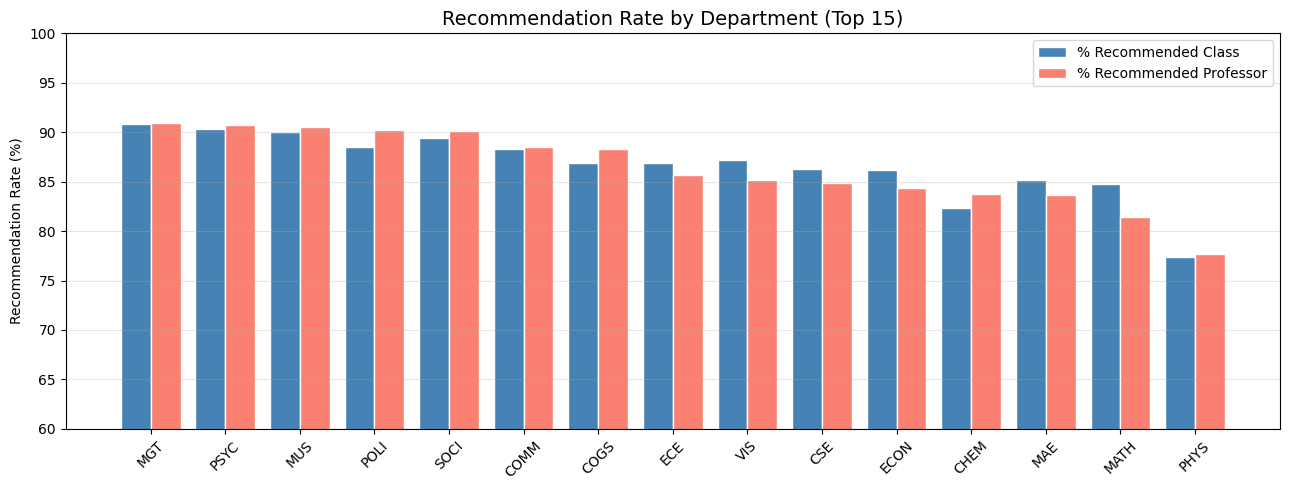

In [8]:
dept_rec = (
    df_clean[df_clean['Department'].isin(TOP_DEPTS)]
    .groupby('Department')[['Pct_Rec_Class', 'Pct_Rec_Prof']]
    .mean()
    .sort_values('Pct_Rec_Prof', ascending=False)
)

x = range(len(dept_rec))
width = 0.4

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar([i - width/2 for i in x], dept_rec['Pct_Rec_Class'],
       width=width, label='% Recommended Class', color='steelblue', edgecolor='white')
ax.bar([i + width/2 for i in x], dept_rec['Pct_Rec_Prof'],
       width=width, label='% Recommended Professor', color='salmon', edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(dept_rec.index, rotation=45)
ax.set_ylim(60, 100)
ax.set_title('Recommendation Rate by Department (Top 15)', fontsize=14)
ax.set_ylabel('Recommendation Rate (%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/dept_rec_rate.png', dpi=150)
plt.show()

## 5. Division Analysis (Lower vs Upper vs Graduate)

### 5.1 GPA Distribution by Division

C:\Users\admin\AppData\Local\Temp\ipykernel_28700\276531906.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


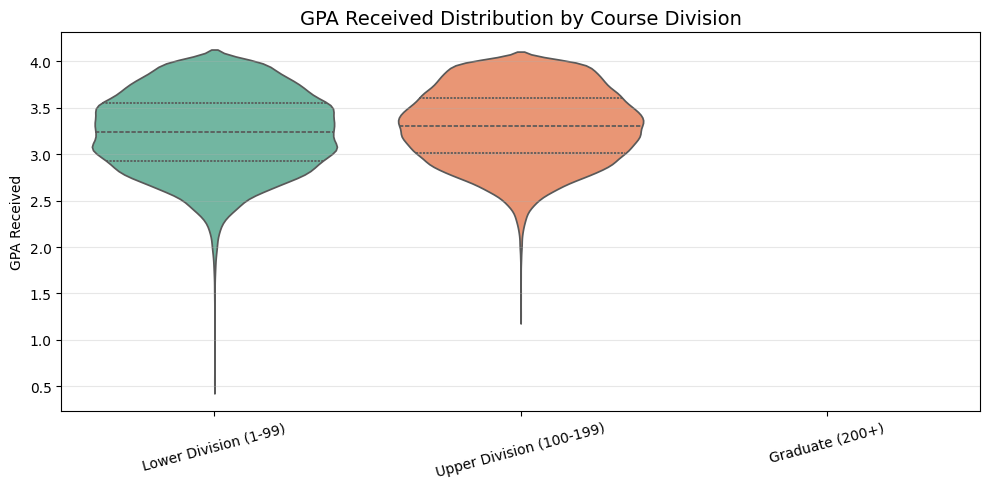

                            count   mean    std   min   25%   50%   75%  max
Division                                                                    
Lower Division (1-99)     13985.0  3.232  0.420  0.55  2.93  3.24  3.55  4.0
Upper Division (100-199)  27194.0  3.296  0.394  1.28  3.01  3.30  3.60  4.0


In [9]:
div_order = ['Lower Division (1-99)', 'Upper Division (100-199)', 'Graduate (200+)']
df_div = df_clean[df_clean['Division'].isin(div_order)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df_div, x='Division', y='GPA_Received',
    order=div_order, palette='Set2', ax=ax, inner='quartile'
)
ax.set_title('GPA Received Distribution by Course Division', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('GPA Received')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/division_gpa_violin.png', dpi=150)
plt.show()

print(df_div.groupby('Division')['GPA_Received'].describe().round(3))

### 5.2 Study Hours by Division

C:\Users\admin\AppData\Local\Temp\ipykernel_28700\1789888097.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


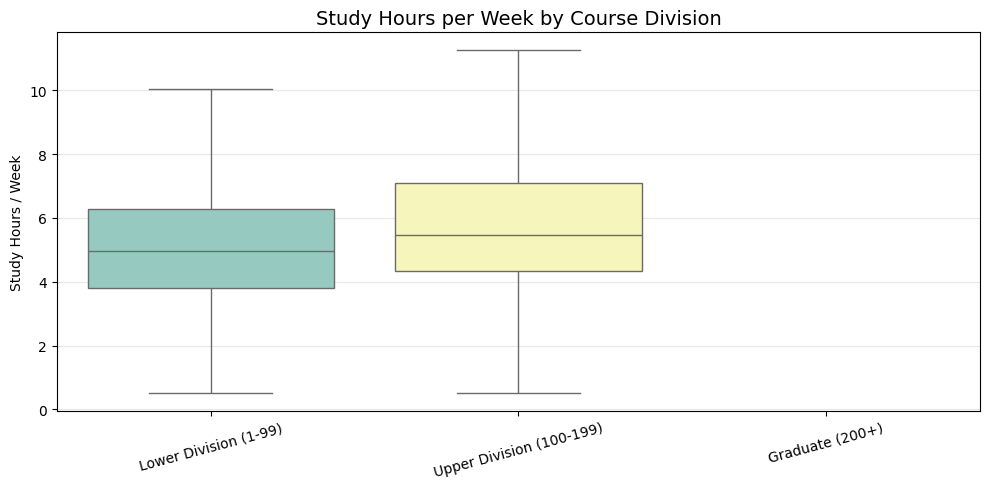

In [10]:
df_div_hours = df_div.dropna(subset=['Study Hours per Week'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_div_hours, x='Division', y='Study Hours per Week',
    order=div_order, palette='Set3', ax=ax, showfliers=False
)
ax.set_title('Study Hours per Week by Course Division', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Study Hours / Week')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/division_study_hours.png', dpi=150)
plt.show()

### 5.3 GPA Trend Over Time by Division (with LLM Markers)

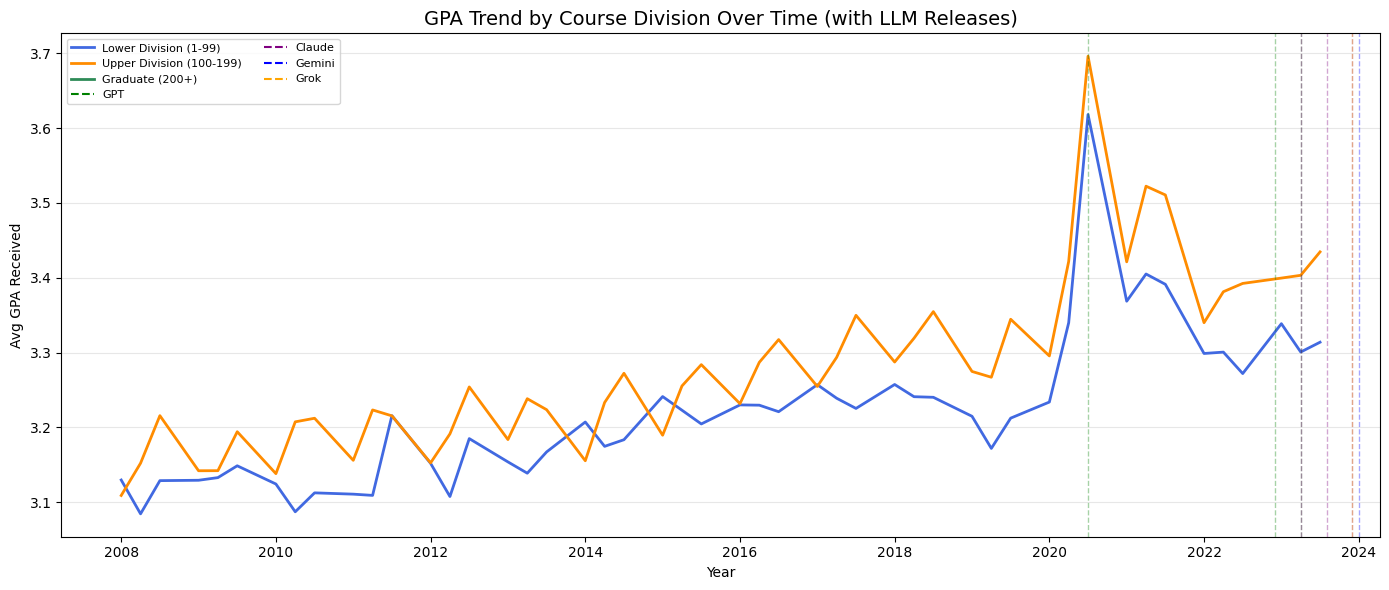

In [11]:
div_trend = (
    df_div
    .groupby(['Quarter_Num', 'Division'])['GPA_Received']
    .mean()
    .reset_index()
)

div_palette = {
    'Lower Division (1-99)':    'royalblue',
    'Upper Division (100-199)': 'darkorange',
    'Graduate (200+)':          'seagreen',
}

fig, ax = plt.subplots(figsize=(14, 6))

for div, color in div_palette.items():
    sub = div_trend[div_trend['Division'] == div].sort_values('Quarter_Num')
    ax.plot(sub['Quarter_Num'], sub['GPA_Received'],
            label=div, color=color, linewidth=2)

# LLM markers
for t, model, brand in all_llm_events:
    ax.axvline(t, color=llm_colors[brand], alpha=0.35, linewidth=1, linestyle='--')

# Combined legend
div_handles, div_labels = ax.get_legend_handles_labels()
ax.legend(handles=div_handles + llm_handles,
          labels=div_labels + list(llm_colors.keys()),
          loc='upper left', fontsize=8, ncol=2)

ax.set_title('GPA Trend by Course Division Over Time (with LLM Releases)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Avg GPA Received')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/division_gpa_trend_llm.png', dpi=150)
plt.show()

### 5.4 GPA by Division — Focus Departments

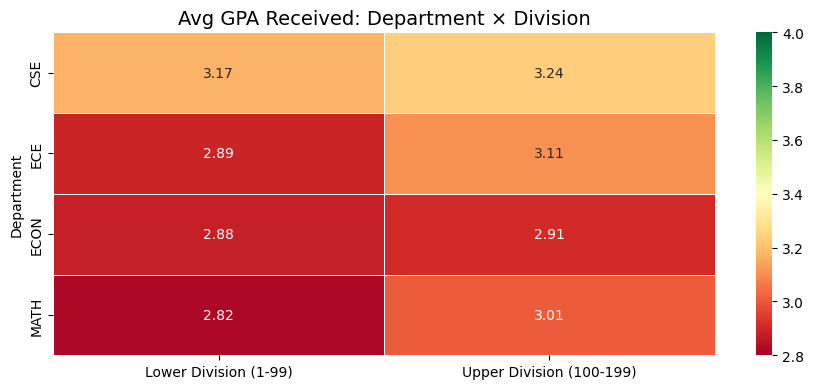

In [12]:
# Heatmap: avg GPA per (department x division)
df_focus = df_clean[
    df_clean['Department'].isin(FOCUS_DEPTS) &
    df_clean['Division'].isin(div_order)
]

pivot = (
    df_focus.groupby(['Department', 'Division'])['GPA_Received']
    .mean()
    .unstack('Division')
)
# 只保留实际存在的列，避免 KeyError
available_divs = [d for d in div_order if d in pivot.columns]
pivot = pivot[available_divs]


fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=2.8, vmax=4.0, linewidths=0.5, ax=ax
)
ax.set_title('Avg GPA Received: Department × Division', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Department')
plt.tight_layout()
plt.savefig('figures/dept_division_gpa_heatmap.png', dpi=150)
plt.show()

## 6. Pre- vs Post-LLM Comparison

Split at **Nov 2022** (ChatGPT / GPT-3.5 release — first widely accessible LLM).

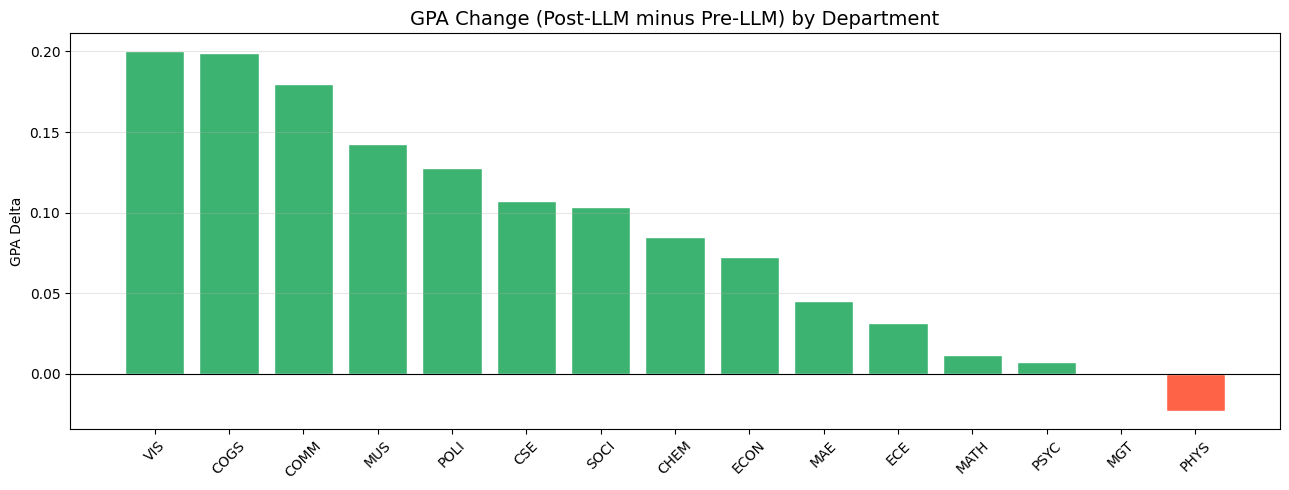

Era         Pre-LLM  Post-LLM (after Nov 2022)  Delta
Department                                           
VIS           3.545                      3.745  0.200
COGS          3.329                      3.529  0.199
COMM          3.347                      3.527  0.180
MUS           3.636                      3.779  0.142
POLI          3.315                      3.442  0.128
CSE           3.206                      3.313  0.107
SOCI          3.327                      3.430  0.103
CHEM          3.003                      3.088  0.085
ECON          2.901                      2.973  0.073
MAE           3.173                      3.218  0.045
ECE           3.040                      3.072  0.031
MATH          2.907                      2.918  0.012
PSYC          3.248                      3.256  0.007
MGT           3.288                      3.289  0.000
PHYS          3.109                      3.086 -0.023


In [13]:
LLM_CUTOFF = 2022 + 11/12  # Nov 2022

df_clean['Era'] = df_clean['Quarter_Num'].apply(
    lambda x: 'Post-LLM (after Nov 2022)' if x >= LLM_CUTOFF else 'Pre-LLM'
)

# Mean GPA per department per era
era_dept = (
    df_clean[df_clean['Department'].isin(TOP_DEPTS)]
    .groupby(['Department', 'Era'])['GPA_Received']
    .mean()
    .unstack('Era')
)

# Delta = Post - Pre
era_dept['Delta'] = era_dept.get('Post-LLM (after Nov 2022)', 0) - era_dept.get('Pre-LLM', 0)
era_dept = era_dept.sort_values('Delta', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['tomato' if d < 0 else 'mediumseagreen' for d in era_dept['Delta']]
ax.bar(era_dept.index, era_dept['Delta'], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('GPA Change (Post-LLM minus Pre-LLM) by Department', fontsize=14)
ax.set_ylabel('GPA Delta')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/dept_pre_post_llm_delta.png', dpi=150)
plt.show()

print(era_dept[['Pre-LLM', 'Post-LLM (after Nov 2022)', 'Delta']].round(3))

## 7. Summary Statistics

In [14]:
print('=== Overall GPA Statistics ===')
print(df_clean['GPA_Received'].describe().round(3))

print('\n=== GPA by Division ===')
print(df_clean[df_clean['Division'].isin(div_order)]
      .groupby('Division')['GPA_Received']
      .agg(['mean', 'median', 'std', 'count'])
      .round(3))

print('\n=== Pre vs Post LLM (all departments) ===')
print(df_clean.groupby('Era')['GPA_Received']
      .agg(['mean', 'count'])
      .round(3))

=== Overall GPA Statistics ===
count    41179.000
mean         3.274
std          0.404
min          0.550
25%          2.980
50%          3.290
75%          3.590
max          4.000
Name: GPA_Received, dtype: float64

=== GPA by Division ===
                           mean  median    std  count
Division                                             
Lower Division (1-99)     3.232    3.24  0.420  13985
Upper Division (100-199)  3.296    3.30  0.394  27194

=== Pre vs Post LLM (all departments) ===
                            mean  count
Era                                    
Post-LLM (after Nov 2022)  3.379   3132
Pre-LLM                    3.266  38047
